# CreditMetrics

### Pytania teoretyczne:

#### Wyjaśnić pojęcie ratingów, jakie poziomy ratingów stosują najbardziej znane agencje ratingowe?

Ad: Ratingi to system oceny wiarygodności kredytowej instytucji / państwa. Jest nadawany przez agencję ratingową na podstawie
oceny ryzyka ekonomicznego, politycznego i społecznego.
Firmy /Pańswta którym są wystawiane noty można podzielić głownie na 2 grupy:
- standard inwestycyjny (bezpieczniejsze, ale mniejsze zyski)
- standard spekulacyjny (ryzkowniejsze, ale większe zyski)

Takie agencje ratingowe powinny być obiektywnym (nie mogą firmy / pańswa na nie naciskać) i stabilnym (ratingi nie powinny zmieniać się zbyt często, bo niesie to ze sobą konswekwencję) podmiotem oceniającym.

System skąłda się z not (na podstawie S&P i Fitch, Moody’s zapisuje noty w zbliżony sposób):
- AAA (najlepsza nota)
- AA
- A
- BBB
- BB
- B
- CCC
- D (bankructwo - niewypłacalność)

Dodatkowo są oceny pośrednie czyli tak jak w skzole -5/+5 tak tutaj mamy np. A-, BB+ itp.

Te agencję także na podsatwie swoich historyczych danych tworzą także swoje tablice przejść, czyli tablice ktore nas informują jakie jest prawdopodobieństwo, że firma zmieni swój rating w czasie X na rating Y, oraz druga tabela, która mówi nam jakie jest prawdopodobieństwo bankróctwa w przeciągu następnych X lat.


#### Wyjaśnić ideę modelu CreditMetrics. Na czym on bazuje i w jaki sposób opisuje ryzyko kredytowe?

Ad: Model CreditMetrics został opracowany w celu określania ryzyka kredytowego nie tylko pojedynczych ekspozycji, ale całego ich portfela. Model ten opiera się na całościowej koncepcji ryzyka kredytowego – w przeciwieństwie do uproszczonych modeli, wycenia on ryzyko uwzględniając nie tylko samo prawdopodobieństwo bankructwa, ale też ewentualne pogorszenie (lub poprawę) ratingu kredytowego w wybranym horyzoncie czasu.
CreditMetrics bazuje na:Prawdopodobieństwach migracji do różnych klas ratingowych (tzw. macierz przejścia), bazujących na danych historycznych. Zgodnie z wyciągiem w Twoim pliku .csv, dla obligacji o ratingu np. BBB szansa pozostania w klasie wynosi aż 88,48%, podczas gdy szansa bankructwa wynosi zaledwie 0,15%.Przyszłych krzywych zwrotu (stóp procentowych) dla poszczególnych klas ratingowych, używanych do wyceny (dyskontowania) instrumentów na wypadek zmiany ich ratingu.Stopach odzysku kapitału (recovery rates), które określają, jaką część środków można odzyskać w przypadku faktycznego ogłoszenia niewypłacalności podmiotu (Default).

### Zadanie praktyczne:
- Z wykorzystaniem modelu CreditMetrics wyznaczyć 99,9% VaR i ES dla portfela składającego się z portfela trzech poniżej opisanych obligacji skarbowych:
	- 3-letnia obligacja o ratingu BBB (cena wykupu 100 000 zł, subordinated),
	- 5-letnia obligacja o ratingu B (cena wykupu 50 000 zł, senior secured),
	- 2-letnia obligacja o ratingu CCC (cena wykupu 50 000 zł, senior unsecured).
- Opisać kolejne kroki rozwiązywanego zadania.
- Zbadać, w jaki sposób zmieniłyby się wyniki, jeśli założylibyśmy, że inwestycje w portfelu są skorelowane (tj. współczynniki korelacji między inwestycjami w portfelu wynoszą: r12 = 0.2, r13 = 0.15, r23 = 0.4). Jak uzyskane wyniki łączą się z pojęciem "dywersyfikacji ryzyka".
- Na podstawie dokumentacji technicznej CreditMetrics na przykładzie opisać, jakie są sposoby wyznaczania korelacji w modelu (podobno roździał nr 9 z ang).

# Opis rozwiązania (punkt 2 polecenia)

Przyjmujemy horyzont 1 rok. Wartość portfela po roku zależy od tego, jakie ratingi będą mieć emitenci naszych obligacji. Rating może się zmienić zgodnie z **macierzą migracji**, a nowy rating oznacza inną krzywą stóp dyskontowych (czyli inną cenę obligacji). Jeśli rating spadnie do *Default* - bankructwo, dostajemy tylko część nominału zgodnie ze stopą odzysku (zależną od seniority).

### Kroki rozwiązania
1. **Wczytanie macierzy migracji** z orginalnego pliku z `dane_cm.xlsx`.
2. **Zapisanie ze zdjęc danych** (stopy zwrotu forward, stopy odzysku) — bierzemy wartości zapisane z excelu (na zdjęciach). Są to standardowe stopy z dokumentacji CreditMetrics.
3. **Zdefiniowanie portfela** — 3 obligacje (rating, nominał, lata do wykupu, seniority).
4. **Monte Carlo (N symulacji)** — dla każdej iteracji losujemy nowe ratingi dla 3 obligacji i wyceniamy je po roku, następnie sumujemy do wartości portfela.
5. **Metryki ryzyka** — Obliczamy E[V], kwantyl 0.1%, VaR(99.9%), ES(99.9%).
6. **Wykresy** — Dodatkowe wykresy - histogram portfela, rozkłady per obligacja, empiryczna CDF (by sprawdzić czy pokrywa się wraz z oficialnymi danymi).

#### Założenie
Inwestycje niezależne (brak korelacji). Założenie to dodatkowo omawiam w punkcie 4 praktycznego zadania, czyli metody wyznaczania korelacji w CreditMetrics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Wczytuję macierz migracji z pliku xlsx
raw = pd.read_excel('dane_cm.xlsx', sheet_name='Arkusz1', header=None)
ratings = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']
destinations = ratings + ['Def']
migration = pd.DataFrame(
    raw.iloc[1:8, 1:9].values.astype(float),
    index=ratings,
    columns=destinations
)

print("Macierz migracji (prawdopodobieństwa przejścia do nowego ratingu po 1 roku):")
display(migration)

Macierz migracji (prawdopodobieństwa przejścia do nowego ratingu po 1 roku):


,AAA,AA,A,BBB,BB,B,CCC,Def
AAA,0.9340,0.0594,0.0064,0.0000,0.0002,0.0000,0.0000,0.0000
AA,0.0161,0.9055,0.0746,0.0026,0.0009,0.0001,0.0000,0.0002
A,0.0007,0.0228,0.9244,0.0463,0.0045,0.0012,0.0001,0.0000
BBB,0.0005,0.0026,0.0551,0.8848,0.0476,0.0071,0.0008,0.0015
BB,0.0002,0.0005,0.0042,0.0516,0.8691,0.0591,0.0024,0.0129
B,0.0000,0.0004,0.0013,0.0054,0.0635,0.8422,0.0191,0.0681
CCC,0.0000,0.0000,0.0000,0.0062,0.0205,0.0408,0.6920,0.2405


### stopy zwrotu; stopa odzysku, a klasa obligacji

Przepisuje tu na sztywno stopy zastosowane w pliku dostarczonych danych. Dodatkowo sprawdziłem czy faktycznie takie same są podane w stndardach **CreditMetrics Technical Document**, z którego korzystalśmy także na zajęciach.
Tabel z **CreditMetrics Technical Document** (Gupton, Finger, Bhatia, 1997, J.P. Morgan / RiskMetrics Group):

- **One-year forward zero curves by credit rating category** (Tabela 2.3 dokumentacji technicznej). Te same wartości są używane w przykładach w rozdziale 3 *("Stand-alone value distributions")* oraz w rozdziale 9 *("Analytic portfolio calculation")*, ostatni z nich to rozdział, z którego korzystamy w naszym zadaniu.
- **Recovery rates by seniority class** (Tabela 7.1 dokumentacji technicznej) — oryginalnie z badań Carty, Lieberman / Moody's (1996): *"Corporate Bond Defaults and Default Rates"*.

In [ ]:
# Stopy zwrotu [%] — lata 1..4 dla każdej klasy ratingowej
yields = pd.DataFrame([
    [3.60, 4.17, 4.73, 5.12],
    [3.65, 4.22, 4.78, 5.17],
    [3.72, 4.32, 4.93, 5.32],
    [4.10, 4.67, 5.25, 5.63],
    [5.55, 6.02, 6.78, 7.27],
    [6.05, 7.02, 8.03, 8.52],
    [15.05, 15.02, 14.03, 13.52],
], index=ratings, columns=[1, 2, 3, 4]) / 100

# Stopy odzysku wg seniority (% nominału w razie default)
recovery = {
    'Senior Secured':      0.5380,
    'Senior Unsecured':    0.5113,
    'Senior Subordinated': 0.3852,
    'Subordinated':        0.3274,
    'Junior Subordinated': 0.1709,
}

print("Stopy zwrotu (forward):")
print((yields * 100).round(2))
print("\nStopy odzysku:")
for k, v in recovery.items():
    print(f"  {k}: {v:.2%}")

Stopy zwrotu (forward):
         1      2      3      4
AAA   3.60   4.17   4.73   5.12
AA    3.65   4.22   4.78   5.17
A     3.72   4.32   4.93   5.32
BBB   4.10   4.67   5.25   5.63
BB    5.55   6.02   6.78   7.27
B     6.05   7.02   8.03   8.52
CCC  15.05  15.02  14.03  13.52

Stopy odzysku:
  Senior Secured: 53.80%
  Senior Unsecured: 51.13%
  Senior Subordinated: 38.52%
  Subordinated: 32.74%
  Junior Subordinated: 17.09%


In [ ]:
# Definiujemy portfel z 3 obligacji
# years_left = lata do wykupu po horyzoncie 1 rok (czyli obecna długość - 1)
portfolio = [
    {'name': 'BBB 100k Subordinated',       'rating': 'BBB', 'face': 100_000, 'years_left': 2, 'seniority': 'Subordinated'},
    {'name': 'B 50k Senior Secured',        'rating': 'B',   'face': 50_000,  'years_left': 4, 'seniority': 'Senior Secured'},
    {'name': 'CCC 50k Senior Unsecured',    'rating': 'CCC', 'face': 50_000,  'years_left': 1, 'seniority': 'Senior Unsecured'},
]

# Wypisujemy konfigurację każdej z obligacji
for b in portfolio:
    print(f"  {b['name']}: rating={b['rating']}, nominał={b['face']:,} zł, "
          f"lata do wykupu ={b['years_left']}, seniority={b['seniority']}")

  BBB 100k Subordinated: rating=BBB, nominał=100,000 zł, lata do wykupu (po horyzoncie)=2, seniority=Subordinated
  B 50k Senior Secured: rating=B, nominał=50,000 zł, lata do wykupu (po horyzoncie)=4, seniority=Senior Secured
  CCC 50k Senior Unsecured: rating=CCC, nominał=50,000 zł, lata do wykupu (po horyzoncie)=1, seniority=Senior Unsecured


In [ ]:
# Symulacja Monte Carlo (bez korelacji) + metryki ryzyka
np.random.seed(42)
# Ilość symulacji, ustawiamy tak jak na przykładzie z wykładów -> 10_000
N = 10_000
K = len(portfolio)

bond_values = np.zeros((N, K))
ratings_drawn = np.empty((N, K), dtype=object)

for k, bond in enumerate(portfolio):
    # Krok 1: losuję N nowych ratingów z rozkładu danego wierszem macierzy migracji
    row = migration.loc[bond['rating']].values
    new_ratings = np.random.choice(destinations, size=N, p=row)
    ratings_drawn[:, k] = new_ratings

    # Krok 2: wycena wektorowa
    # - Default → nominał × stopa odzysku
    # - inny rating → nominał / (1 + forward_yield)^lata_do_wykupu
    yield_map = yields[bond['years_left']].to_dict()
    y_vec = np.array([yield_map.get(r, np.nan) for r in new_ratings])
    bond_values[:, k] = np.where(
        new_ratings == 'Def',
        bond['face'] * recovery[bond['seniority']],
        bond['face'] / (1 + y_vec) ** bond['years_left']
    )

# Krok 3: wartość portfela = suma 3 obligacji w każdej iteracji
portfolio_values = bond_values.sum(axis=1)

# Krok 4: metryki ryzyka
EV = portfolio_values.mean()
Q = np.quantile(portfolio_values, 0.001)
VaR_999 = EV - Q
ES_999 = EV - portfolio_values[portfolio_values < Q].mean()

print(f"Wartość oczekiwana portfela  E[V]:   {EV:>12,.2f} zł")
print(f"Kwantyl 0.1%                  Q:     {Q:>12,.2f} zł")
print(f"VaR (99.9%) = E[V] - Q:              {VaR_999:>12,.2f} zł")
print(f"ES  (99.9%) = E[V] - mean(V<Q):      {ES_999:>12,.2f} zł")

Wartość oczekiwana portfela  E[V]:     165,926.13 zł
Kwantyl 0.1%                  Q:       112,251.49 zł
VaR (99.9%) = E[V] - Q:                 53,674.64 zł
ES  (99.9%) = E[V] - mean(V<Q):         70,121.06 zł


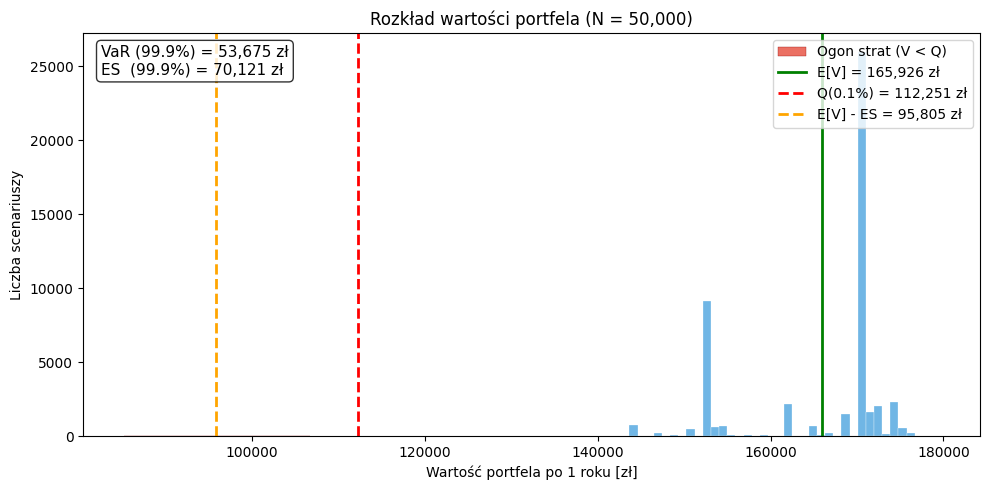

In [5]:
# Histogram wartości portfela z zaznaczeniem VaR i ES
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(portfolio_values, bins=100, color='#3498db', alpha=0.7, edgecolor='white', linewidth=0.3)

# Ogon strat poniżej Q(0.1%) — zaznaczony na czerwono
tail = portfolio_values[portfolio_values < Q]
ax.hist(tail, bins=30, color='#e74c3c', alpha=0.8, edgecolor='darkred', linewidth=0.3, label=f'Ogon strat (V < Q)')

ax.axvline(EV,       color='green',  linestyle='-',  linewidth=2, label=f'E[V] = {EV:,.0f} zł')
ax.axvline(Q,        color='red',    linestyle='--', linewidth=2, label=f'Q(0.1%) = {Q:,.0f} zł')
ax.axvline(EV-ES_999,color='orange', linestyle='--', linewidth=2, label=f'E[V] - ES = {EV-ES_999:,.0f} zł')

ax.set_xlabel('Wartość portfela po 1 roku [zł]')
ax.set_ylabel('Liczba scenariuszy')
ax.set_title(f'Rozkład wartości portfela (N = {N:,})')

# Tabelka z VaR i ES w rogu
txt = f'VaR (99.9%) = {VaR_999:,.0f} zł\nES  (99.9%) = {ES_999:,.0f} zł'
ax.text(0.02, 0.97, txt, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

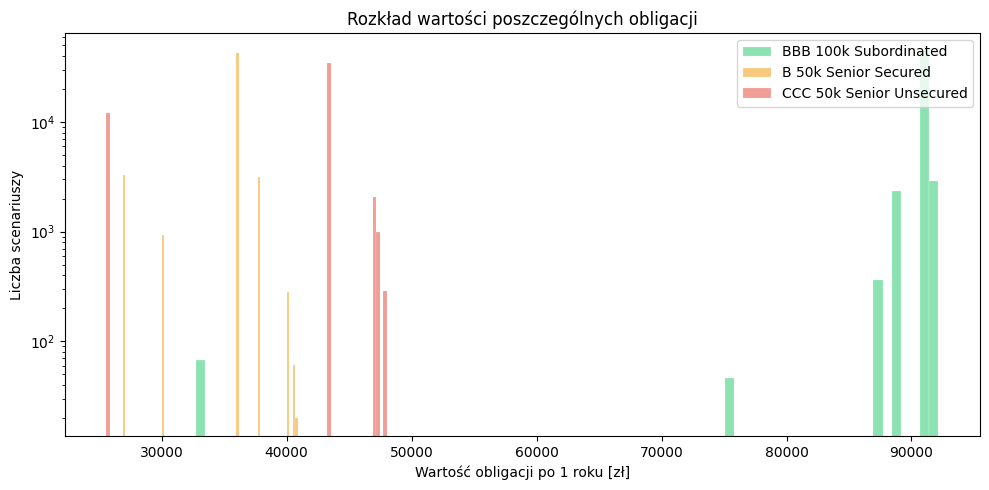

In [6]:
# Rozkład wartości per obligacja — widać, która obligacja ma najcięższe ogony
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
for k, bond in enumerate(portfolio):
    ax.hist(bond_values[:, k], bins=80, alpha=0.55, color=colors[k], label=bond['name'], edgecolor='white', linewidth=0.2)

ax.set_xlabel('Wartość obligacji po 1 roku [zł]')
ax.set_ylabel('Liczba scenariuszy')
ax.set_title('Rozkład wartości poszczególnych obligacji')
ax.legend(loc='upper right')
ax.set_yscale('log')  # log skala, żeby widać było rzadkie defaulty
plt.tight_layout()
plt.show()

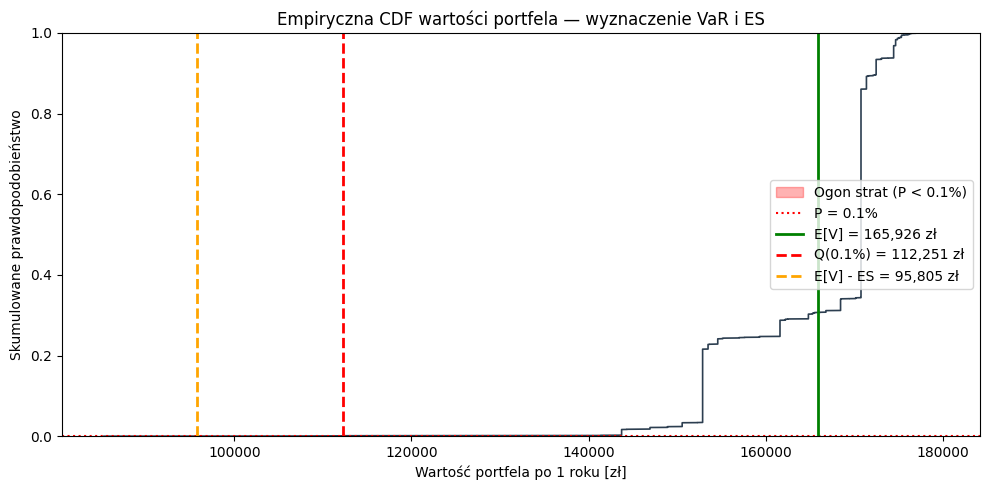

In [7]:
# Empiryczna CDF wartości portfela — wyznaczenie VaR i ES z wykresu
x_sorted = np.sort(portfolio_values)
y_cdf = np.arange(1, N + 1) / N

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_sorted, y_cdf, color='#2c3e50', linewidth=1.2)

# Strefa ogona (pod kwantylem 0.1%)
mask = x_sorted < Q
ax.fill_between(x_sorted[mask], 0, y_cdf[mask], color='red', alpha=0.3, label='Ogon strat (P < 0.1%)')

ax.axhline(0.001, color='red',    linestyle=':',  linewidth=1.5, label='P = 0.1%')
ax.axvline(EV,    color='green',  linestyle='-',  linewidth=2,   label=f'E[V] = {EV:,.0f} zł')
ax.axvline(Q,     color='red',    linestyle='--', linewidth=2,   label=f'Q(0.1%) = {Q:,.0f} zł')
ax.axvline(EV-ES_999, color='orange', linestyle='--', linewidth=2, label=f'E[V] - ES = {EV-ES_999:,.0f} zł')

ax.set_xlabel('Wartość portfela po 1 roku [zł]')
ax.set_ylabel('Skumulowane prawdopodobieństwo')
ax.set_title('Empiryczna CDF wartości portfela — wyznaczenie VaR i ES')
ax.legend(loc='center right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

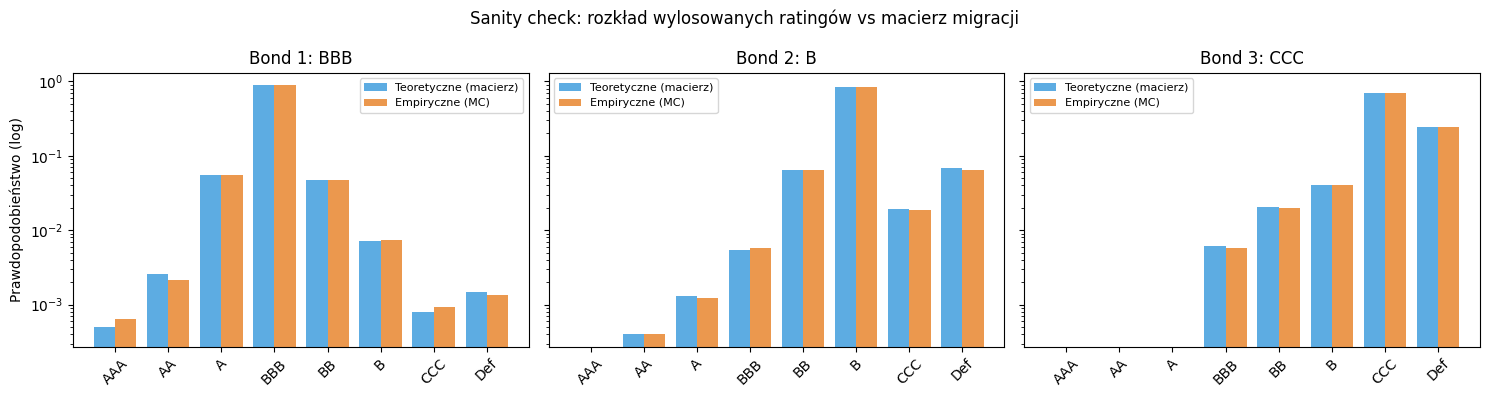

In [8]:
# Sanity check: empiryczny rozkład wylosowanych ratingów vs teoretyczny (macierz migracji)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
width = 0.4
x = np.arange(len(destinations))

for k, bond in enumerate(portfolio):
    ax = axes[k]
    # Empiryczne
    counts = pd.Series(ratings_drawn[:, k]).value_counts().reindex(destinations, fill_value=0)
    emp = counts.values / N
    # Teoretyczne
    theo = migration.loc[bond['rating']].values

    ax.bar(x - width/2, theo, width, label='Teoretyczne (macierz)', color='#3498db', alpha=0.8)
    ax.bar(x + width/2, emp,  width, label='Empiryczne (MC)',      color='#e67e22', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(destinations, rotation=45)
    ax.set_title(f"Bond {k+1}: {bond['rating']}")
    ax.legend(fontsize=8)
    ax.set_yscale('log')

axes[0].set_ylabel('Prawdopodobieństwo (log)')
fig.suptitle('Sanity check: rozkład wylosowanych ratingów vs macierz migracji', fontsize=12)
plt.tight_layout()
plt.show()

## Metody wyznaczania korelacji w CreditMetrics (punkt 4)

Na podstawie **CreditMetrics Technical Document** (rozdział 8 *"Asset value model"* i rozdział 9 *"Analytic portfolio calculation"*) — korelacje w modelu dotyczą nie bezpośrednio ratingów, ale **wartości aktywów emitentów** (framework Mertonowski). Zmiany wartości aktywów traktujemy jako zmienne losowe o rozkładzie normalnym, a macierz migracji ratingów zamieniamy na **progi** na tej zmiennej. Joint transition matrix dla pary emitentów wynika z całki z dwuwymiarowego rozkładu normalnego o zadanej korelacji aktywów.

Do **oszacowania samej korelacji aktywów** CreditMetrics proponuje kilka metod (od najdokładniejszej do najprostszej):

### 1. Bezpośrednia korelacja zwrotów akcji (equity returns)
Dla dużych emitentów giełdowych korelację aktywów przybliżamy korelacją historycznych zwrotów ich akcji. Proste i dokładne, ale wymaga, żeby oba podmioty były notowane.

### 2. Podejście indeksowe (industry / country indices)
Gdy nie mamy szeregów zwrotów pojedynczych firm, każdego emitenta mapujemy na **miks indeksów sektorowych i krajowych** z wagami. Korelację dwóch emitentów liczymy z macierzy korelacji indeksów i ich wag.

- *Przykład*: emitent A = 60% indeks chemiczny PL + 40% indeks energetyczny PL; emitent B = 100% indeks chemiczny US. Korelację A–B obliczamy jako ważoną kombinację korelacji tych indeksów.

### 3. Model czynnikowy (factor model)
Zwrot firmy dekomponujemy na:
- **część systemową** — zależną od kilku czynników (np. indeksów sektorowych, krajowych, globalnych),
- **część idiosynkratyczną** — specyficzną dla firmy, nieskorelowaną z innymi emitentami.

Korelacja między firmami wynika wtedy tylko z ich wspólnej ekspozycji na czynniki systemowe. Im większa część idiosynkratyczna, tym niższa korelacja.

### 4. Stała korelacja (constant correlation)
Najprostsze podejście: wszystkie pary emitentów mają **tę samą korelację aktywów** (CreditMetrics używa np. 0.30 w przykładach rozdziału 9). Używane, gdy brakuje danych o sektorach/krajach lub portfel jest mały. W dużym portfelu prowadzi do nierealistycznej struktury zależności (niedoszacowanie lub przeszacowanie ryzyka koncentracji).

### 5. Od korelacji aktywów do joint transition matrix
Mając korelację aktywów ρ, dla pary emitentów wyznaczamy macierz łącznych przejść (8×8 dla 8 ratingów) przez całkowanie dwuwymiarowej gęstości normalnej nad prostokątnymi obszarami wyznaczonymi przez progi:

$$P(R_1 = r_1, R_2 = r_2) = \int_{Z_{r_1-1}}^{Z_{r_1}} \int_{Z_{r_2-1}}^{Z_{r_2}} \phi_2(x, y; \rho) \, dx \, dy$$

gdzie $\phi_2$ to gęstość dwuwymiarowego rozkładu normalnego, a $Z$ to progi wyznaczone z macierzy migracji jednoczynnikowej. W praktyce liczone numerycznie (np. funkcje biwariate normal w R/Pythonie).